Recording ID: 003bec244
Audio shape: (2880022,)
Labels for this recording:
  recording_id  species_id  songtype_id   t_min    f_min    t_max    f_max
0    003bec244          14            1  44.544  2531.25  45.1307  5531.25


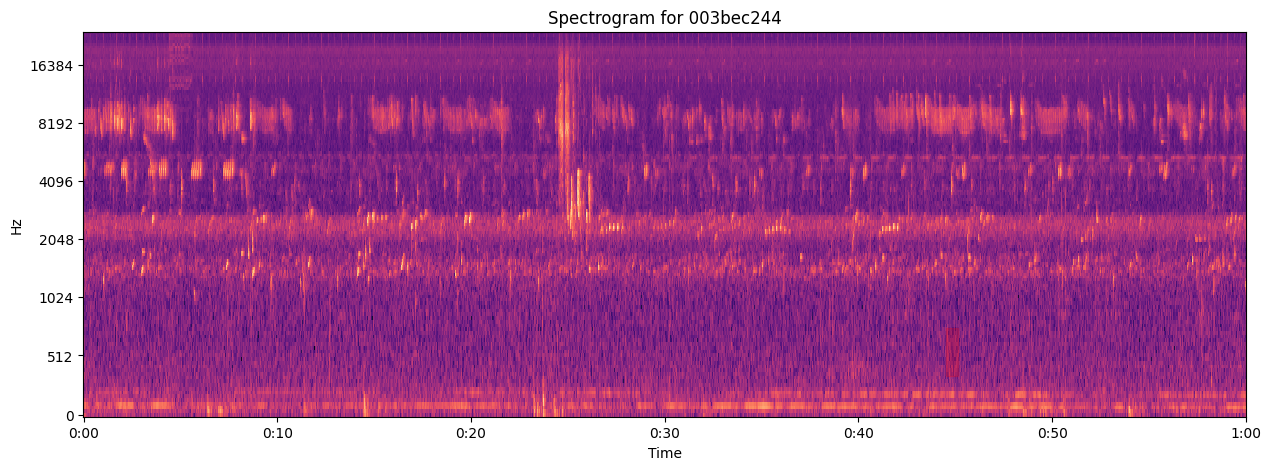

In [ ]:
import tensorflow as tf
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Load the metadata (This path was already correct) ---
df_train = pd.read_csv('../data/rfcx-species-audio-detection/train_tp.csv')

# --- 2. Define how to parse a TFRecord ---
def parse_tfrecord_fn(example):
    feature_description = {
        "recording_id": tf.io.FixedLenFeature([], tf.string),
        "audio_wav": tf.io.FixedLenFeature([], tf.string),
        "label_info": tf.io.FixedLenFeature([], tf.string),
    }
    example = tf.io.parse_single_example(example, feature_description)
    
    audio_wav = tf.io.decode_raw(example['audio_wav'], tf.int16)
    audio_wav = tf.cast(audio_wav, tf.float32) / 32768.0
    
    return audio_wav, example['recording_id']

# --- 3. Create a TensorFlow Dataset object (FIXED PATH) ---
tfrec_filepaths = tf.io.gfile.glob('../data/rfcx-species-audio-detection/tfrecords/train/*.tfrec')
dataset = tf.data.TFRecordDataset(tfrec_filepaths)
dataset = dataset.map(parse_tfrecord_fn)

# --- 4. Let's inspect one example ---
for audio_sample, recording_id_tensor in dataset.take(1):
    audio_np = audio_sample.numpy()
    recording_id = recording_id_tensor.numpy().decode('utf-8')
    
    print(f"Recording ID: {recording_id}")
    print(f"Audio shape: {audio_np.shape}")
    
    labels = df_train[df_train.recording_id == recording_id]
    print("Labels for this recording:")
    print(labels)

    # --- 5. Visualize it! ---
    SR = 48000
    fig, ax = plt.subplots(figsize=(15, 5))
    mel_spec = librosa.feature.melspectrogram(y=audio_np, sr=SR)
    librosa.display.specshow(librosa.power_to_db(mel_spec, ref=np.max), sr=SR, x_axis='time', y_axis='mel', ax=ax)
    
    for _, row in labels.iterrows():
        ax.axvspan(row.t_min, row.t_max, alpha=0.2, color='red', ymin=row.f_min/24000, ymax=row.f_max/24000)

    ax.set_title(f"Spectrogram for {recording_id}")
    plt.show()

In [3]:
import glob

# The exact same path pattern we used before
file_pattern = '../data/rfcx-species-audio-detection/tfrecords/train-*.tfrec'

# Use the glob library to find all files matching the pattern
found_files = glob.glob(file_pattern)

print(f"Found {len(found_files)} files matching the pattern.")

# Print the first 5 file paths it found (if any)
print(found_files[:5])

Found 0 files matching the pattern.
[]
